# Modelo de XGBoost vs Black-Scholes

Se utiliza el modelo de Machine Learning **XGBoost** para modelar el efecto conocido como "sonrisa de volatilidad de mercado" e identificar desviaciones respecto al modelo clásico de **Black-Scholes**. Se estudia también si es posible obtener una mejor predicción para el precio de las opciones utilizando el modelo clásico, al considerar la volatilidad predicha por el modelo **XGBoost**.

**Importación de librerias:**

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd

# Preparación de la base de datos:

Se utiliza la libreria __yfinance__ para importar datos financieros de la empresa **Microsoft** (MSFT)

In [2]:
#Descargar datos del subyacente
ticker = yf.Ticker('MSFT')

#Precio spot actual
hist_spot = ticker.history(period='1d')
S0 = hist_spot['Close'].iloc[-1]
print(f' Precio spot MSFT ($S_0$): ${S0:.2f}')

#vencimiento entre 30 y 90 días
from datetime import datetime, timedelta

hoy = datetime.today()
vencimientos = ticker.options  # lista de strings 'YYYY-MM-DD'

#Filtrar vencimientos en la ventana [30, 90] días
opciones_validas = [
    v for v in vencimientos
    if 30 <= (datetime.strptime(v, '%Y-%m-%d') - hoy).days <= 90
]

#Si no hay en esa ventana, tomar el más cercano disponible
if not opciones_validas:
    opciones_validas = [vencimientos[1] if len(vencimientos) > 1 else vencimientos[0]]

fecha_exp = opciones_validas[0]
T = (datetime.strptime(fecha_exp, '%Y-%m-%d') - hoy).days / 365
print(f' Fecha de vencimiento seleccionada: {fecha_exp}  (T = {T:.4f} años)')

#Extraer cadena de opciones Call
chain = ticker.option_chain(fecha_exp)
calls_raw = chain.calls.copy()

print(f'\n Contratos Call disponibles: {len(calls_raw)}')
print(f'Columnas disponibles: {list(calls_raw.columns)}')
calls_raw.head(3)

#Parámetros del modelo
r = 0.045      # Tasa libre de riesgo (Fed Funds aproximado)
q = 0.0075     # Dividend yield de MSFT (~0.75%)

#Limpieza de la cadena de opciones
df = calls_raw[[
    'strike', 'bid', 'ask', 'lastPrice',
    'impliedVolatility', 'volume', 'openInterest'
]].copy()

#Calcular Mid-Price (precio real de referencia)
df['midPrice'] = (df['bid'] + df['ask']) / 2

#Filtrar contratos sin liquidez real
df = df[
    (df['bid'] > 0) &
    (df['impliedVolatility'] > 0.01) &
    (df['impliedVolatility'] < 3.0) &    # eliminar valores extremos
    (df['volume'] > 0)
].reset_index(drop=True)

#Variables de entrada para ML
df['Moneyness'] = df['strike'] / S0          # K/S_t
df['T'] = T                                   # Tiempo a vencimiento (constante para este cross-section)
df['log_Moneyness'] = np.log(df['Moneyness']) # log(K/S) — más simétrico

#Variable objetivo
df['IV_mercado'] = df['impliedVolatility']

print(f'Contratos útiles tras filtrado: {len(df)}')
print(f'Moneyness rango: [{df.Moneyness.min():.3f}, {df.Moneyness.max():.3f}]')
print(f'IV mercado rango: [{df.IV_mercado.min():.2%}, {df.IV_mercado.max():.2%}]')


 Precio spot MSFT ($S_0$): $369.92
 Fecha de vencimiento seleccionada: 2026-07-31  (T = 0.0932 años)

 Contratos Call disponibles: 54
Columnas disponibles: ['contractSymbol', 'lastTradeDate', 'strike', 'lastPrice', 'bid', 'ask', 'change', 'percentChange', 'volume', 'openInterest', 'impliedVolatility', 'inTheMoney', 'contractSize', 'currency']
Contratos útiles tras filtrado: 53
Moneyness rango: [0.730, 1.514]
IV mercado rango: [43.43%, 74.90%]


# Modelo XGBoost
**Se utiliza el modelo de XGBoost para intentar modelar la "sonrisa de volatilidad", un efecto real que el modelo de Black-Scholes no es capaz de modelar. Importamos las libererias necesarias para el modelo:**

In [3]:
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import norm
import matplotlib.pyplot as plt

**Definimos la función de Black-Scholes para la comparación con el modelo de ML**

In [4]:
#Definición de función de Black-Scholes para comparación
def black_scholes_call(S, K, T, r, q, sigma):
    #Calcula el precio de una opción Call europea usando Black-Scholes
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call_price = S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return call_price

# Entrenamiento del modelo XGBoost:



**Preparamos los datos para el entrenamiento del modelo:**

In [5]:
#Preparación de datos
features = ['Moneyness', 'log_Moneyness', 'T']
target = 'IV_mercado'

X = df[features].values
y = df[target].values

#Entrenamiento del modelo: 80% de entrenamiento, 20% de prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

**Buscamos los parametros óptimos para el modelo:**

In [6]:
from sklearn.model_selection import GridSearchCV

print("Iniciando búsqueda de hiperparámetros.")

#Definimos el espacio de búsqueda de parámetros
param_grid = {
    'max_depth': [3, 4, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [200, 300, 500],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

#Inicializamos un modelo base XGBoost sin parámetros fijos
xgb_base = xgb.XGBRegressor(random_state=42, n_jobs=-1)

#Configuramos la búsqueda
grid_search = GridSearchCV(
    estimator=xgb_base, 
    param_grid=param_grid, 
    cv=3,                      #Divide los datos de entrenamiento en 3 partes
    scoring='neg_mean_absolute_error', #Buscamos minimizar el MAE
    verbose=1,
    n_jobs=-1                  #Usa todos los núcleos
)

#Entrenamos la búsqueda sobre el set de entrenamiento
grid_search.fit(X_train, y_train)

#Extraemos el mejor modelo y sus parámetros
print(f"Mejores parámetros encontrados:\n{grid_search.best_params_}")


Iniciando búsqueda de hiperparámetros.
Fitting 3 folds for each of 243 candidates, totalling 729 fits
Mejores parámetros encontrados:
{'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.7}


# Definición del modelo XGBoost con los parámetros encontrados:

In [7]:
#Modelo XGBoost con parámetros óptimos
xgb_model = grid_search.best_estimator_
xgb_model.fit(X_train, y_train) 

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,1.0
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


**Se evalua el desempeño del modelo utilizando el Mean Absolute Error(MAE) y $R^2$**

In [8]:
#Evaluamos el desempeño en el set de prueba
y_pred_opt = xgb_model.predict(X_test)
mae_opt = mean_absolute_error(y_test, y_pred_opt)
r2_opt = r2_score(y_test, y_pred_opt)

print(f"\nDesempeño del Modelo Optimizado:")
print(f"MAE (σ_IV): {mae_opt:.4f}")
print(f"R²        : {r2_opt:.4f}")


Desempeño del Modelo Optimizado:
MAE (σ_IV): 0.0151
R²        : 0.8167


**Procesamiento de datos con el modelo XGBoost:**

In [9]:
#Prediccion de la volatilidad utilizando XGboost:
df['IV_ML'] = xgb_model.predict(X)

**Se modela también el precio de las opciones utilizando el modelo de Black-Scholes con la volatilidad predicha por XGBoost, comparandola con la volatilidad $\sigma$ estándar constante.**

In [10]:
#Cálculo de precios
#Volatilidad constante para el benchmark de Black-Scholes
sigma_constante = df['IV_mercado'].mean()


#Precio usando la IV predicha por XGBoost
df['Precio_BS_ML'] = black_scholes_call(S0, df['strike'], df['T'], r, q, df['IV_ML'])
#Precio usando una volatilidad constante promedio
df['Precio_BS_Plano'] = black_scholes_call(S0, df['strike'], df['T'], r, q, sigma_constante)

# Visualizaciones:

Validamos visualmente que el modelo **XGBoost** haya modelado correctamente la "sonrisa de volatilidad"

Mejora relativa: 68.6%


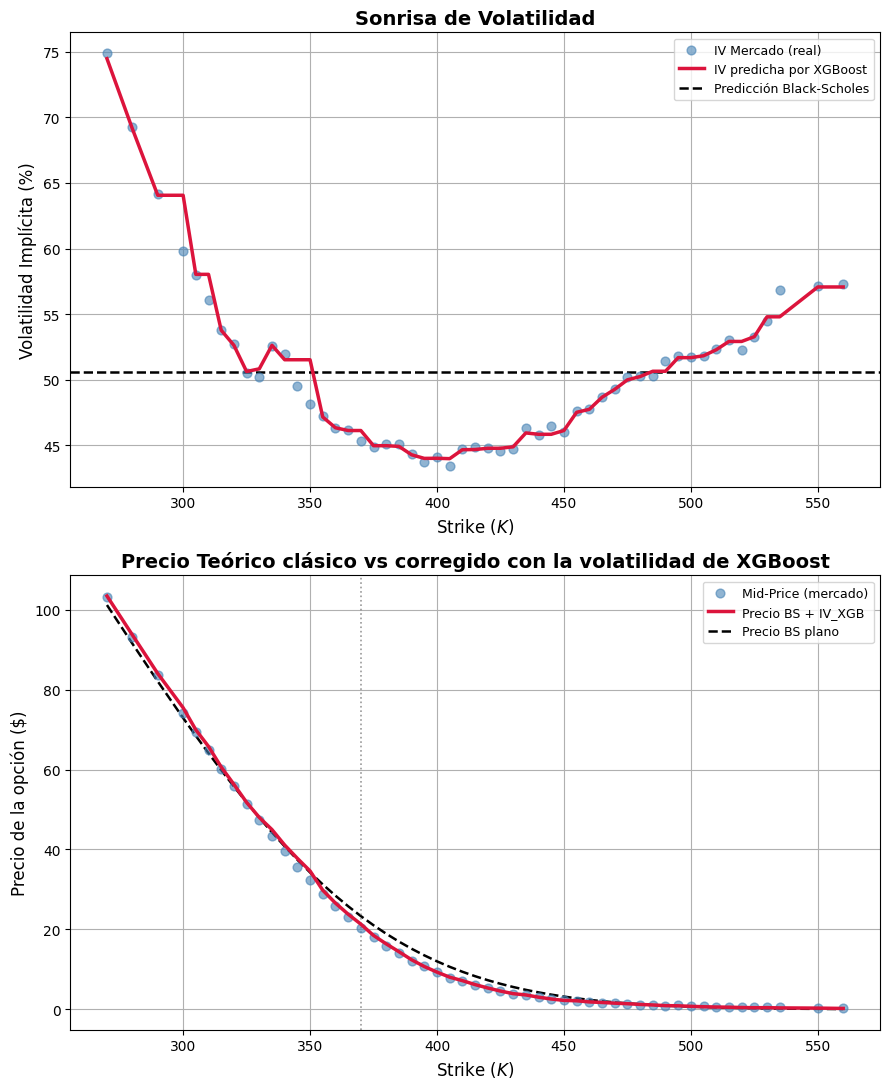

In [11]:
#Visualización
df_plot = df.sort_values('strike')

#fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig, axes = plt.subplots(2, 1, figsize=(9, 11))
#Sonrisa de Volatilidad
ax = axes[0]
ax.scatter(
    df_plot['strike'], df_plot['IV_mercado'] * 100,
    color='steelblue', alpha=0.6, s=40, zorder=3,
    label='IV Mercado (real)'
)
ax.plot(
    df_plot['strike'], df_plot['IV_ML'] * 100,
    color='crimson', lw=2.5, zorder=4,
    label='IV predicha por XGBoost'
)
ax.axhline(
    y=sigma_constante * 100, color='black', lw=1.8,
    linestyle='--', label=f'Predicción Black-Scholes'
)
ax.set_xlabel('Strike ($K$)', fontsize=12)
ax.set_ylabel('Volatilidad Implícita (%)', fontsize=12)
ax.set_title('Sonrisa de Volatilidad', fontsize=14, fontweight='bold')
ax.legend(fontsize=9)

#Comparación de precios
ax2 = axes[1]
ax2.scatter(
    df_plot['strike'], df_plot['midPrice'],
    color='steelblue', alpha=0.6, s=40, zorder=3,
    label='Mid-Price (mercado)'
)
ax2.plot(
    df_plot['strike'], df_plot['Precio_BS_ML'],
    color='crimson', lw=2.5, zorder=4,
    label='Precio BS + IV_XGB'
)
ax2.plot(
    df_plot['strike'], df_plot['Precio_BS_Plano'],
    color='black', lw=1.8, linestyle='--',
    label='Precio BS plano'
)
ax2.axvline(x=S0, color='gray', lw=1.2, linestyle=':', alpha=0.8)
ax2.set_xlabel('Strike ($K$)', fontsize=12)
ax2.set_ylabel('Precio de la opción ($)', fontsize=12)
ax2.set_title('Precio Teórico clásico vs corregido con la volatilidad de XGBoost', fontsize=14, fontweight='bold')
ax2.legend(fontsize=9)


#Mejora relativa de Black-Scholes clasico vs Modificado con sigma de XGboost
mae_plano = mean_absolute_error(df['midPrice'], df['Precio_BS_Plano'])
mae_ml = mean_absolute_error(df['midPrice'], df['Precio_BS_ML'])
print(f'Mejora relativa: {(mae_plano - mae_ml)/mae_plano*100:.1f}%')

plt.tight_layout()
ax.grid(True)
ax2.grid(True)
plt.show()

# Conclusión:
- Se muestra que el modelo de XGBoost es capaz de modelar el comportamiento empírico del mercado y el fenómeno de la "sonrisa de volatilidad", con un desempeño de:

**MAE (σ_IV): 0.0151**

**R²        : 0.8167**

- Se muestra también que el modelo XGBoost fue capaz de corregir la fórmula tradicional de Black-Scholes para replicar los precios del mundo real con una **mejora relativa de un 68.6%**.